# Сравнение PINN и метода конечных разностей (МКР)

## Подготовка

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from pinn_core import PINNSolver, set_seed
import pinn_fdm as cmp
from pinn_fdm import (run_task, print_summary_table,
                      plot_compare_2d, plot_compare_2d_t_snapshots,
                      LR1_TASKS, LR2_TASKS, LR3_TASKS, LR4_TASKS)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', DEVICE)
set_seed(42)
EVAL_N = 200
EVAL_N_2DT = 80
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
all_results = []
def collect_row(result, label):
    ev = result.get('eval', {})
    all_results.append({
        'name': label,
        'fdm_err':  ev.get('fdm_err'),
        'fdm_time': result['fdm']['time'] if result.get('fdm') else 0.0,
        'pinn_err':  ev.get('pinn_err'),
        'pinn_time': result['pinn']['time'] if result.get('pinn') else 0.0,
    })

Устройство: cuda


## Параболические уравнения

Вид уравнения: $u_t = a\,u_{xx} + b\,u_x + c\,u + f(x,t)$. Три задачи отличаются типом граничных условий — от неоднородных Дирихле до условий Робена при наличии конвективного члена.


  Параболическое 1D: неоднородные условия Дирихле
  PDE: u_t = a u_xx,  u(0,t)=0, u(1,t)=1, u(x,0)=x+sin(πx)
--- МКР ---
  МКР-параболика: nx=101, nt=1001, h=0.01, τ=0.001, схема=crank_nicolson, upwind=False
  МКР время: 0.15s
--- PINN ---
Adam (4000 ep, lr=0.001, coll=1500 random)


Adam:   0%|          | 0/4000 [00:00<?, ?it/s]c:\Users\NikitoZ\miniconda3\envs\pinn\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Adam:  50%|█████     | 2011/4000 [00:34<00:32, 61.13it/s]

   2000 | L=9.13e-04 | res=6.60e-04 | cond=2.54e-05


Adam: 100%|██████████| 4000/4000 [01:06<00:00, 60.50it/s]


   4000 | L=3.50e-04 | res=2.69e-04 | cond=8.13e-06
L-BFGS (max 1500)
  L-BFGS   200 | L=3.42e-05
  L-BFGS   400 | L=3.32e-06
  L-BFGS   600 | L=3.32e-06
Done 88.7s | res=2.57e-06 | cond=7.43e-08 | total=3.32e-06
  PINN время: 88.72s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 3.250e-05   Max |Δ|: 9.844e-05
  PINN:   Rel L2: 1.143e-04   Max |Δ|: 4.320e-04


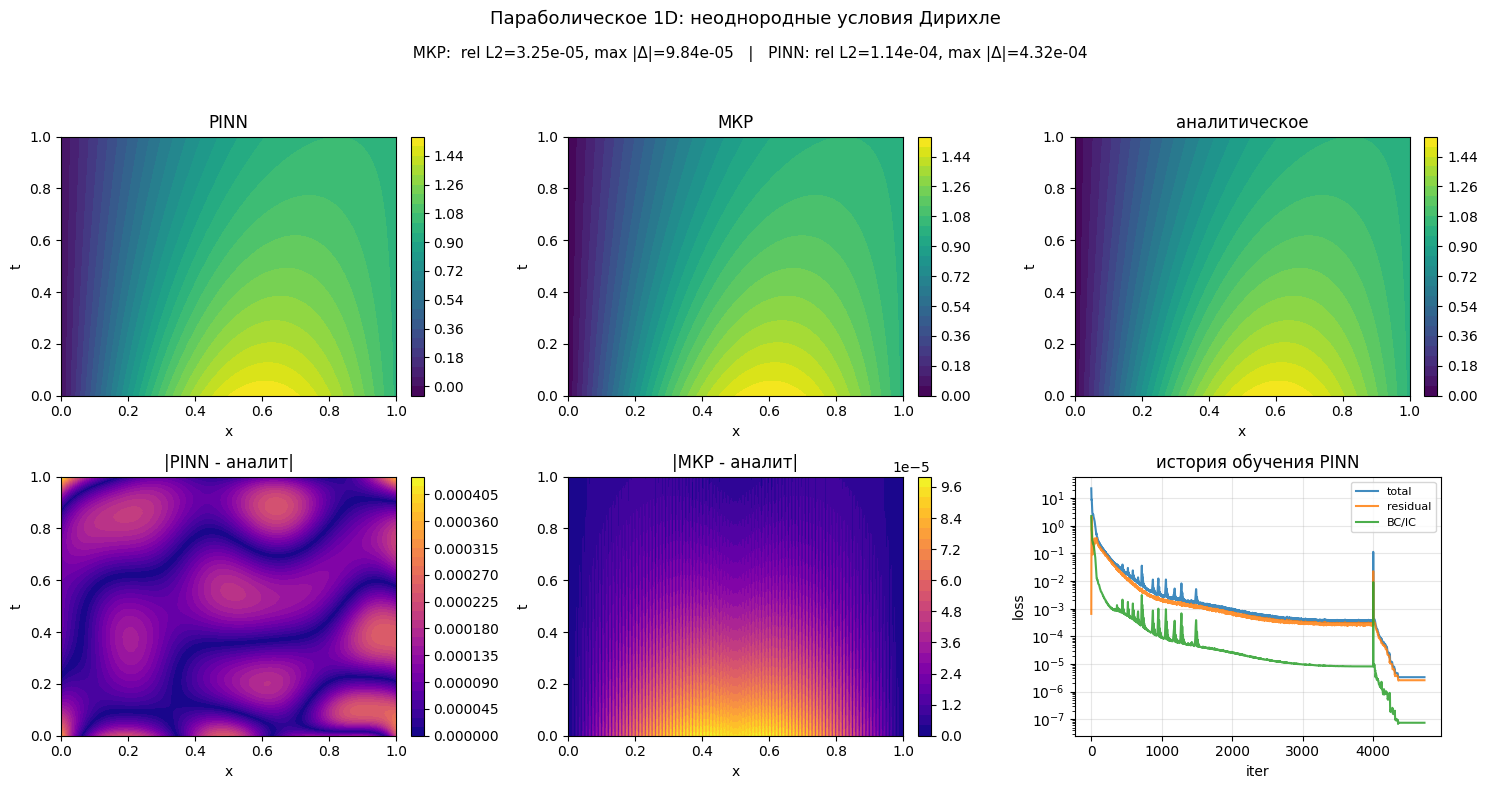


  Параболическое 1D: нестационарные условия Неймана
  PDE: u_t = a u_xx, u_x(0,t)=exp(-at), u_x(π,t)=-exp(-at), u(x,0)=sin x
--- МКР ---
  МКР-параболика: nx=101, nt=2001, h=0.03142, τ=0.001, схема=crank_nicolson, upwind=False
  МКР время: 0.97s
--- PINN ---
Adam (5000 ep, lr=0.001, coll=2000 random)


Adam:  40%|████      | 2006/5000 [00:36<00:51, 58.35it/s]

   2000 | L=2.75e-04 | res=1.60e-04 | cond=7.66e-06


Adam:  80%|████████  | 4009/5000 [01:12<00:16, 59.19it/s]

   4000 | L=9.20e-05 | res=6.16e-05 | cond=2.02e-06


Adam: 100%|██████████| 5000/5000 [01:28<00:00, 56.23it/s]


L-BFGS (max 1500)
  L-BFGS   200 | L=6.32e-06
  L-BFGS   400 | L=1.38e-06
  L-BFGS   600 | L=1.38e-06
Done 109.9s | res=1.09e-06 | cond=1.96e-08 | total=1.38e-06
  PINN время: 109.93s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 2.208e-04   Max |Δ|: 2.356e-04
  PINN:   Rel L2: 3.224e-04   Max |Δ|: 4.295e-04


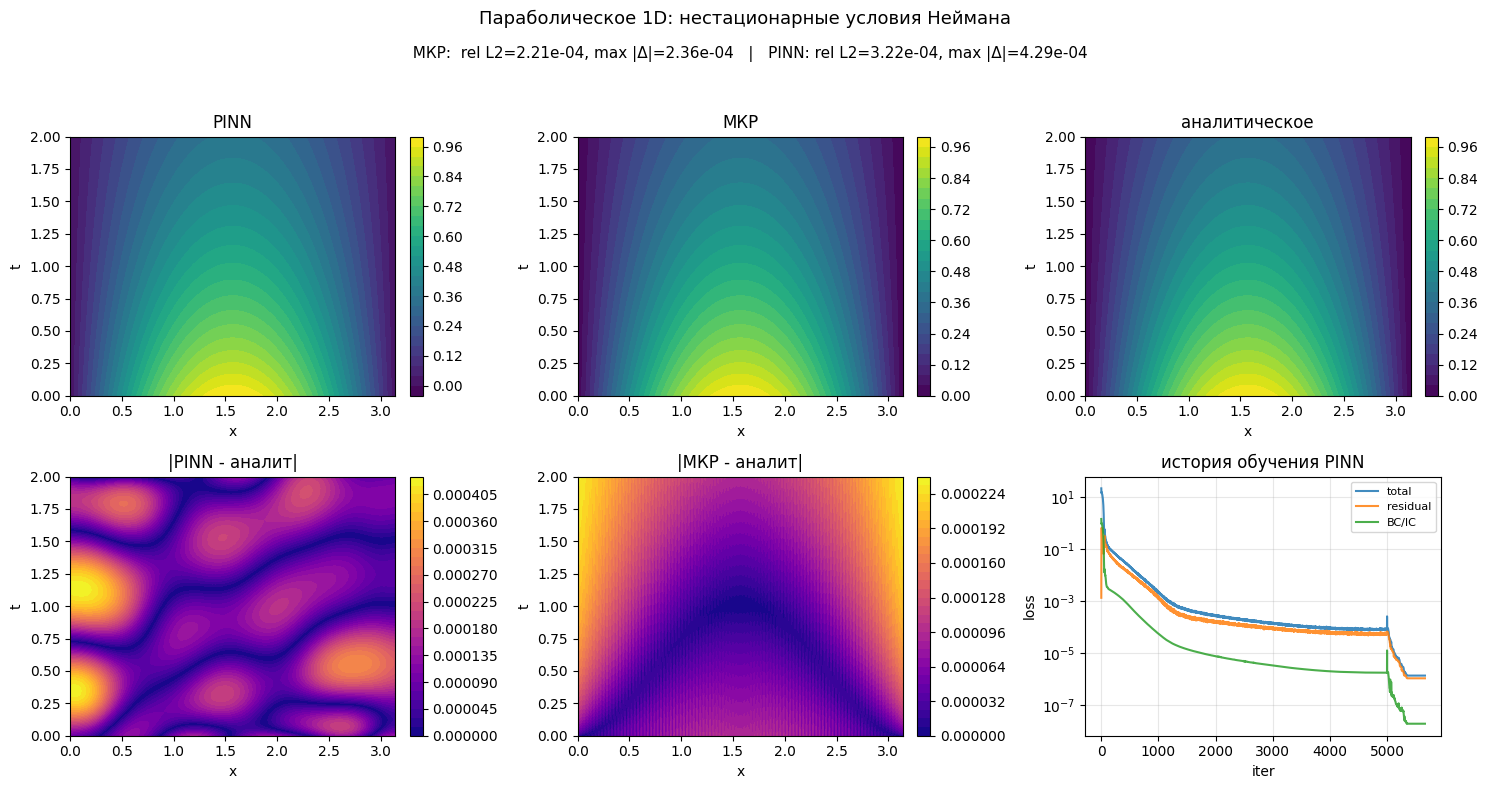


  Параболическое 1D: конвекция-диффузия, условия Робена
  PDE: u_t = a u_xx + b u_x, u_x(0,t)-u(0,t)=-exp(-at)(cos bt+sin bt), u_x(π,t)-u(π,t)= exp(-at)(cos bt+sin bt), u(x,0)=cos x
--- МКР ---
  МКР-параболика: nx=151, nt=2001, h=0.02094, τ=0.001, схема=crank_nicolson, upwind=False
  МКР время: 1.14s
--- PINN ---
Adam (7000 ep, lr=0.001, coll=3000 random)


Adam:  29%|██▊       | 2003/7000 [01:07<02:48, 29.70it/s]

   2000 | L=6.04e-05 | res=1.94e-05 | cond=2.70e-05


Adam:  57%|█████▋    | 4003/7000 [02:16<01:42, 29.27it/s]

   4000 | L=1.62e-05 | res=2.47e-06 | cond=7.84e-06


Adam:  86%|████████▌ | 6006/7000 [03:21<00:32, 30.61it/s]

   6000 | L=1.04e-05 | res=1.29e-06 | cond=5.82e-06


Adam: 100%|██████████| 7000/7000 [03:53<00:00, 29.93it/s]


L-BFGS (max 1500)
  L-BFGS   200 | L=1.15e-05
Done 246.7s | res=1.62e-06 | cond=5.75e-06 | total=1.15e-05
  PINN время: 246.70s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 4.490e-04   Max |Δ|: 1.440e-03
  PINN:   Rel L2: 3.786e-02   Max |Δ|: 1.084e-01


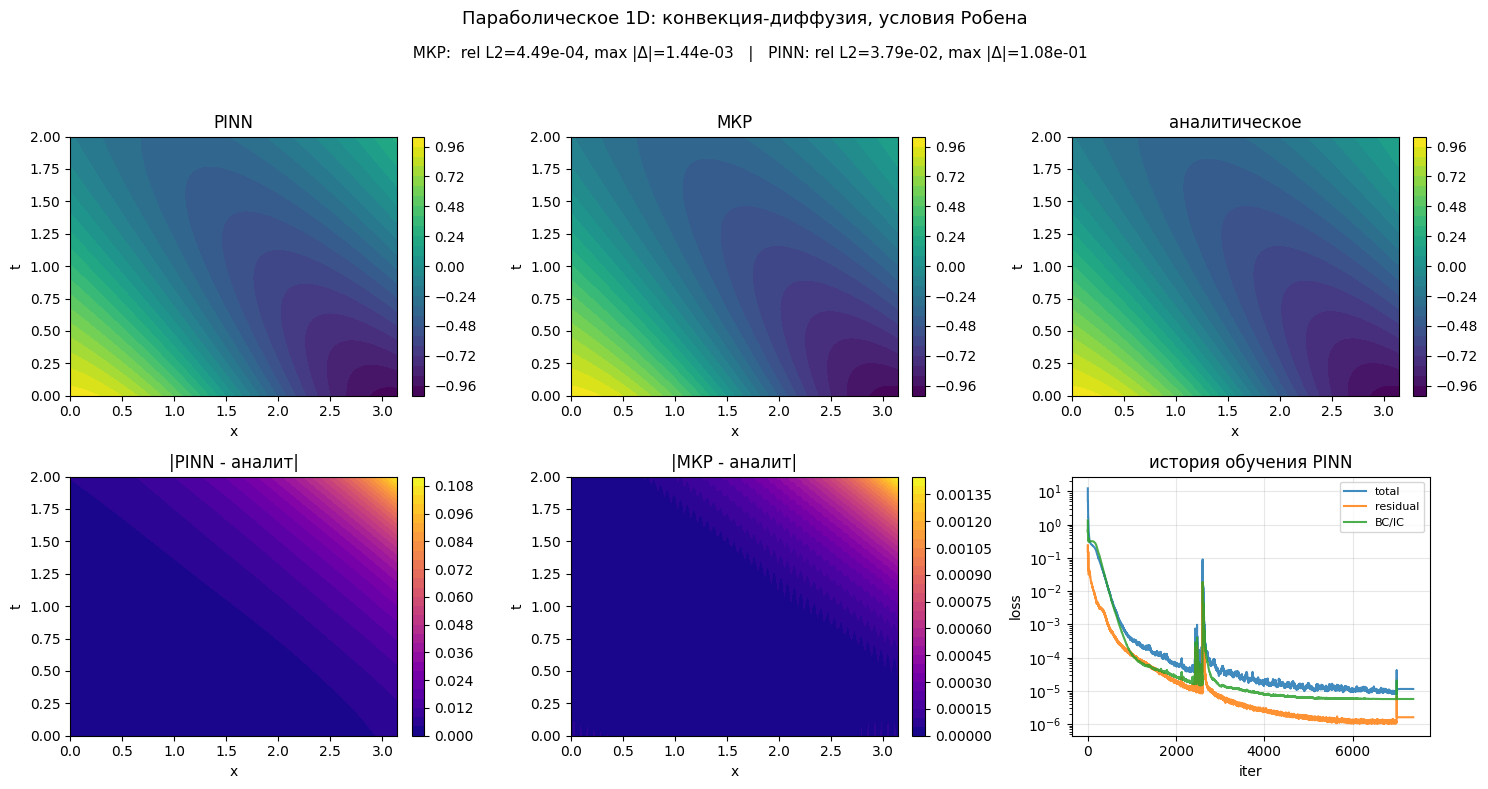

In [3]:
lr1_results = []
for task in LR1_TASKS:
    res = run_task(task, kind='parabolic_1d',
                   PINNSolver_cls=PINNSolver, device=DEVICE,
                   eval_n=EVAL_N, verbose=True)
    lr1_results.append(res)
    collect_row(res, task['name'])
    plot_compare_2d(res, save_to=OUT / f"parabolic_1d_{LR1_TASKS.index(task)+1}.png")

## Гиперболические уравнения

Вид уравнения: $u_{tt} + d\,u_t = a^2 u_{xx} + b\,u_x + c\,u + f(x,t)$. Включены варианты с условиями Робена, с реакционным членом и с демпфированием (затухающие колебания).


  Гиперболическое 1D: условия Робена (α=-1, β=1)
  PDE: u_tt = a² u_xx, u_x-u=0 на обоих концах
--- МКР ---
  МКР-гиперболика: nx=201, nt=4001, h=0.01571, τ=0.0007854, CFL=0.050, d=0.0, b=0.0, c=0.0
  МКР время: 0.09s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=3000 random)


Adam:  25%|██▌       | 2002/8000 [01:34<04:57, 20.15it/s]

   2000 | L=5.61e-04 | res=4.78e-05 | cond=5.23e-04


Adam:  50%|█████     | 4004/8000 [02:58<02:43, 24.43it/s]

   4000 | L=1.62e-04 | res=1.09e-05 | cond=1.64e-04


Adam:  75%|███████▌  | 6002/8000 [04:19<01:20, 24.91it/s]

   6000 | L=9.51e-05 | res=3.49e-06 | cond=1.17e-04


Adam: 100%|██████████| 8000/8000 [05:41<00:00, 23.44it/s]


   8000 | L=1.54e-04 | res=1.84e-06 | cond=1.20e-04
L-BFGS (max 2500)
  L-BFGS   200 | L=1.67e-04
  L-BFGS   400 | L=1.67e-04
  L-BFGS   600 | L=1.67e-04
Done 369.3s | res=2.21e-06 | cond=1.19e-04 | total=1.67e-04
  PINN время: 369.30s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 5.612e-05   Max |Δ|: 1.211e-04
  PINN:   Rel L2: 7.824e-02   Max |Δ|: 4.941e-01


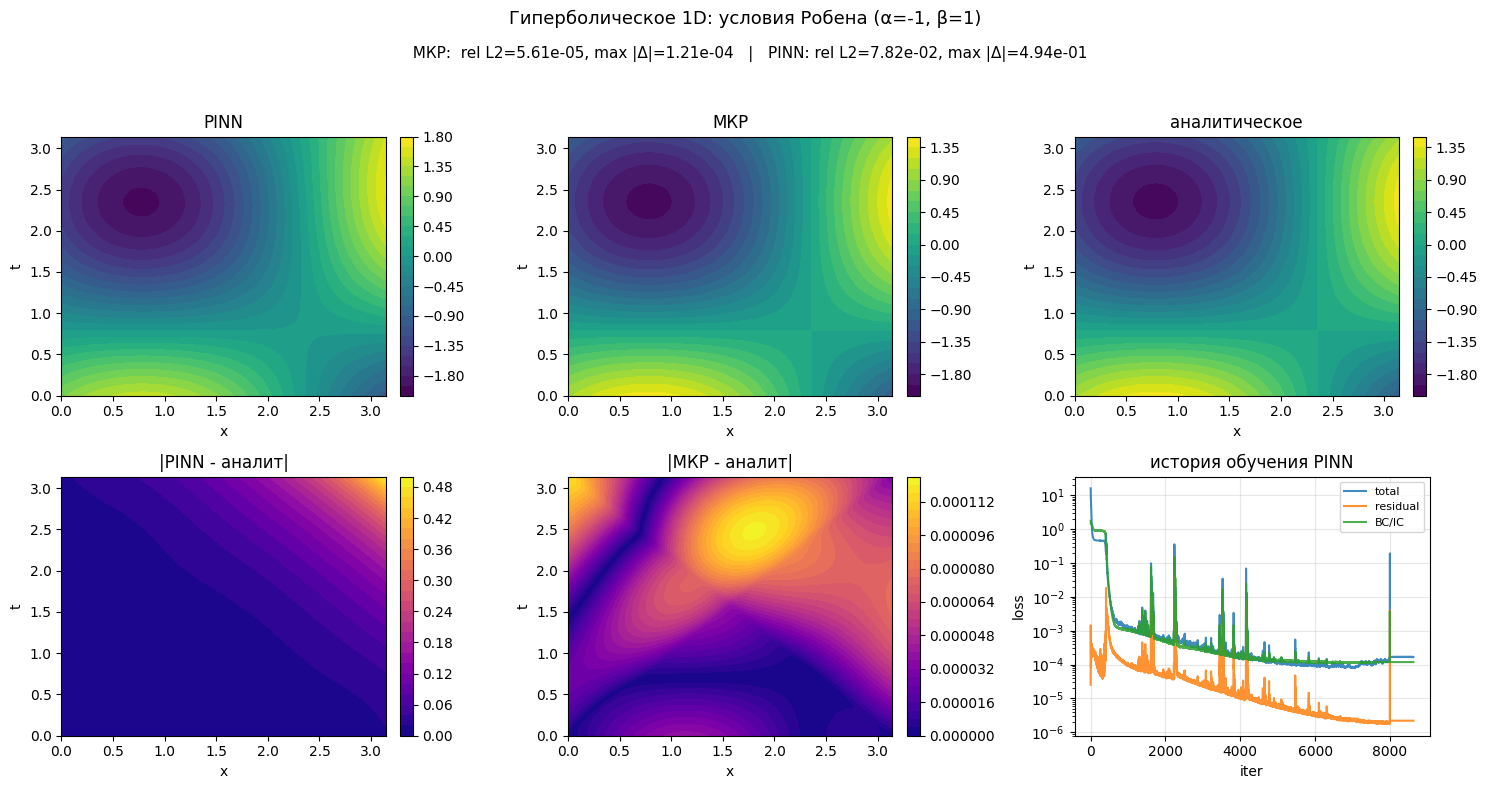


  Гиперболическое 1D: с реакционным членом, нестационарные Дирихле
  PDE: u_tt = u_xx - 3u, u(0,t)=sin(2t), u(π,t)=-sin(2t)
--- МКР ---
  МКР-гиперболика: nx=201, nt=4001, h=0.01571, τ=0.0007854, CFL=0.050, d=0.0, b=0.0, c=-3.0
  МКР время: 0.09s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=3000 random)


Adam:  25%|██▌       | 2003/8000 [01:09<03:27, 28.90it/s]

   2000 | L=1.16e-02 | res=9.33e-03 | cond=2.43e-03


Adam:  50%|█████     | 4003/8000 [02:19<02:18, 28.78it/s]

   4000 | L=3.61e-04 | res=3.89e-04 | cond=4.58e-05


Adam:  75%|███████▌  | 6004/8000 [03:30<01:07, 29.61it/s]

   6000 | L=1.85e-04 | res=2.19e-04 | cond=1.25e-05


Adam: 100%|██████████| 8000/8000 [04:38<00:00, 28.71it/s]


   8000 | L=1.72e-04 | res=2.19e-04 | cond=5.17e-06
L-BFGS (max 2500)
  L-BFGS   200 | L=1.95e-04
  L-BFGS   400 | L=1.95e-04
  L-BFGS   600 | L=1.95e-04
Done 307.6s | res=2.82e-04 | cond=5.03e-06 | total=1.95e-04
  PINN время: 307.58s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 1.306e-05   Max |Δ|: 1.471e-05
  PINN:   Rel L2: 3.833e-03   Max |Δ|: 6.679e-03


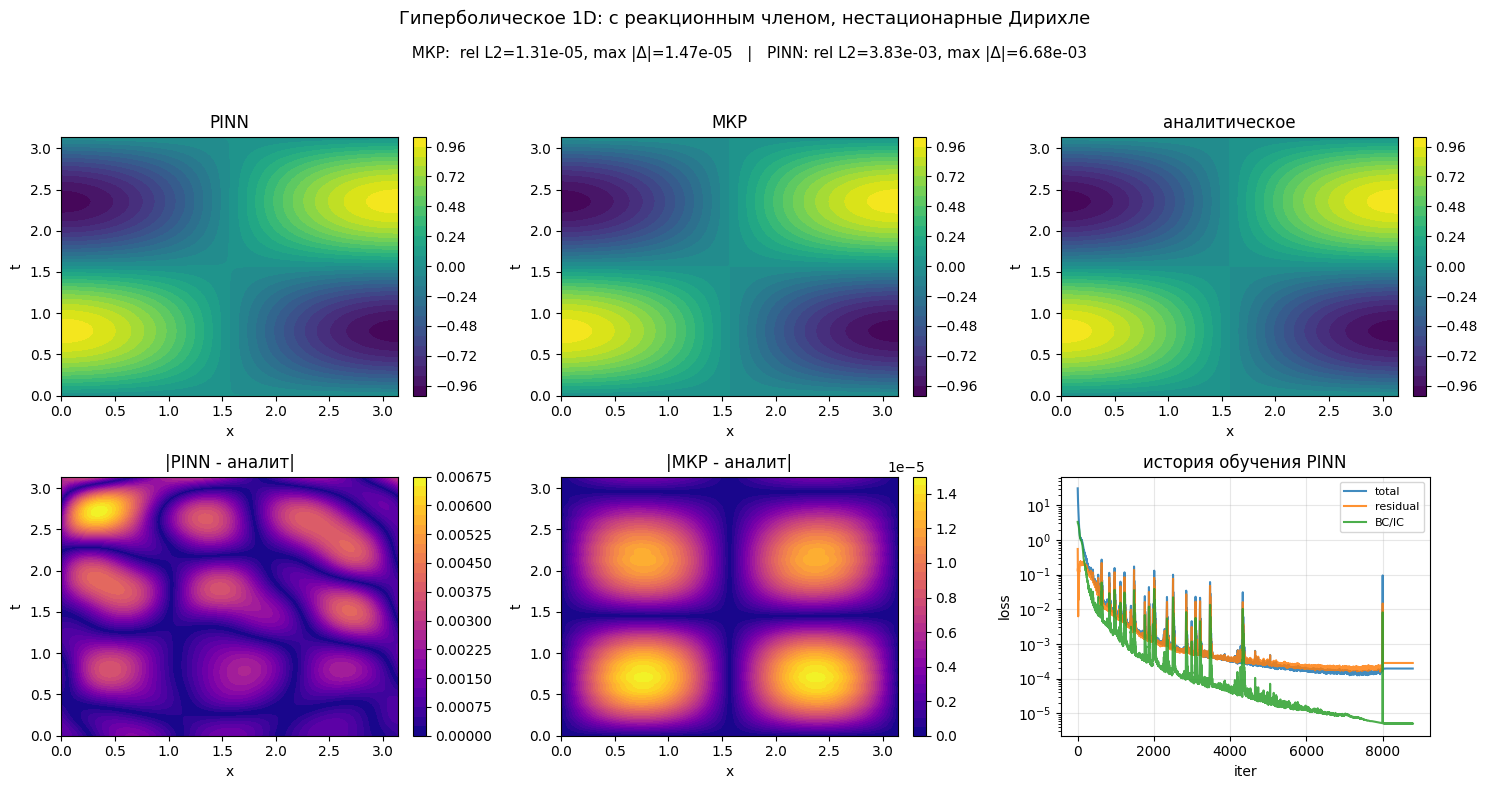


  Гиперболическое 1D: с демпфированием и конвекцией
  PDE: u_tt + 2u_t = u_xx + 2u_x − 3u, однор. Дирихле
--- МКР ---
  МКР-гиперболика: nx=201, nt=4001, h=0.01571, τ=0.0007854, CFL=0.050, d=2.0, b=2.0, c=-3.0
  МКР время: 0.08s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=3000 random)


Adam:  25%|██▌       | 2002/8000 [01:19<03:56, 25.38it/s]

   2000 | L=1.82e-04 | res=1.78e-04 | cond=2.64e-05


Adam:  50%|█████     | 4003/8000 [02:40<02:41, 24.80it/s]

   4000 | L=6.66e-05 | res=6.00e-05 | cond=1.28e-05


Adam:  75%|███████▌  | 6004/8000 [04:02<01:20, 24.74it/s]

   6000 | L=3.03e-05 | res=2.65e-05 | cond=6.14e-06


Adam: 100%|██████████| 8000/8000 [05:24<00:00, 24.69it/s]


   8000 | L=4.17e-05 | res=2.39e-05 | cond=3.77e-06
L-BFGS (max 2500)
  L-BFGS   200 | L=3.72e-05
  L-BFGS   400 | L=3.72e-05
  L-BFGS   600 | L=3.72e-05
Done 358.5s | res=3.48e-05 | cond=3.52e-06 | total=3.72e-05
  PINN время: 358.51s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 3.777e-05   Max |Δ|: 7.050e-06
  PINN:   Rel L2: 1.664e-02   Max |Δ|: 5.090e-03


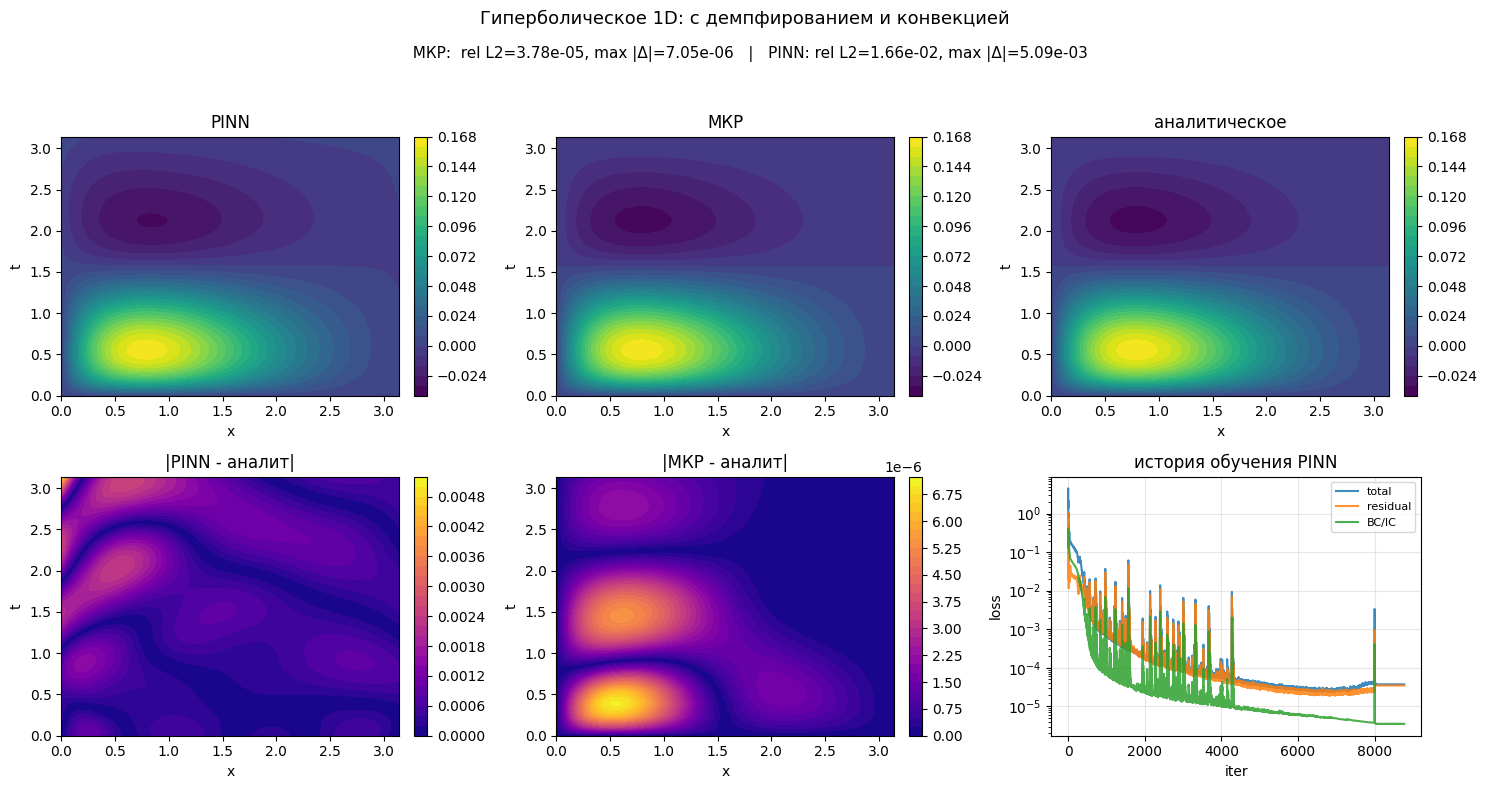

In [4]:
lr2_results = []
for task in LR2_TASKS:
    res = run_task(task, kind='hyperbolic_1d',
                   PINNSolver_cls=PINNSolver, device=DEVICE,
                   eval_n=EVAL_N, verbose=True)
    lr2_results.append(res)
    collect_row(res, task['name'])
    plot_compare_2d(res, save_to=OUT / f"hyperbolic_1d_{LR2_TASKS.index(task)+1}.png")

## Эллиптические уравнения

Вид уравнения: $a\,\Delta u + b_x u_x + b_y u_y + c\,u = f(x,y)$. Задачи охватывают смешанные граничные условия (Нейман+Дирихле), уравнение с членом $\lambda u$ и полное уравнение конвекции-диффузии-реакции.


  Эллиптическое 2D: смешанные условия Нейман+Дирихле
  PDE: Δu = 0,  u_x(0,y)=0, u(1,y)=1-y², u_y(x,0)=0, u(x,1)=x²-1
--- МКР ---
  МКР-эллиптика: nx=51, ny=51, hx=0.02, hy=0.02
  МКР время: 0.08s
--- PINN ---
Adam (5000 ep, lr=0.001, coll=2000 random)


Adam:  40%|████      | 2007/5000 [00:45<01:05, 45.46it/s]

   2000 | L=1.74e-03 | res=1.56e-03 | cond=1.16e-05


Adam:  80%|████████  | 4007/5000 [01:29<00:21, 45.22it/s]

   4000 | L=9.99e-04 | res=9.41e-04 | cond=3.91e-06


Adam: 100%|██████████| 5000/5000 [01:51<00:00, 44.96it/s]


L-BFGS (max 1500)
  L-BFGS   200 | L=5.13e-05
  L-BFGS   400 | L=2.06e-05
  L-BFGS   600 | L=1.14e-05
  L-BFGS   800 | L=7.10e-06
  L-BFGS  1000 | L=5.40e-06
  L-BFGS  1200 | L=4.36e-06
Done 163.4s | res=4.13e-06 | cond=1.51e-08 | total=4.36e-06
  PINN время: 163.41s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 1.005e-04   Max |Δ|: 1.000e-04
  PINN:   Rel L2: 5.349e-05   Max |Δ|: 1.028e-04


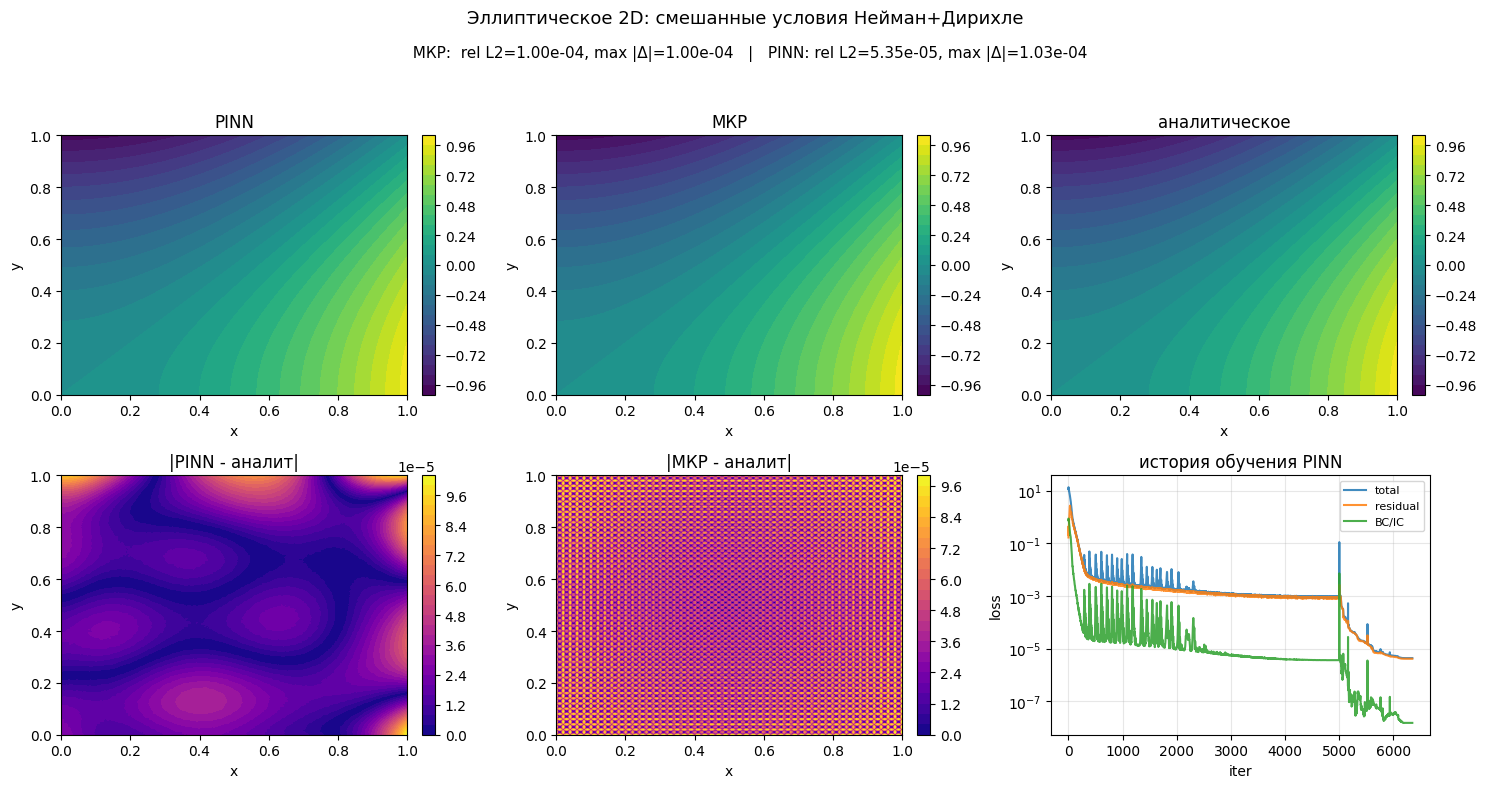


  Эллиптическое 2D: Δu+λu=0, условия Дирихле
  PDE: Δu + 2u = 0, чисто Дирихле
--- МКР ---
  МКР-эллиптика: nx=51, ny=51, hx=0.03142, hy=0.03142
  МКР время: 0.08s
--- PINN ---
Adam (6000 ep, lr=0.001, coll=2500 random)


Adam:  33%|███▎      | 2003/6000 [01:05<02:15, 29.56it/s]

   2000 | L=1.28e-04 | res=7.30e-05 | cond=4.07e-05


Adam:  67%|██████▋   | 4005/6000 [02:12<01:02, 31.75it/s]

   4000 | L=2.29e-05 | res=1.43e-05 | cond=3.90e-06


Adam: 100%|██████████| 6000/6000 [03:18<00:00, 30.23it/s]


   6000 | L=1.32e-05 | res=1.04e-05 | cond=2.32e-06
L-BFGS (max 1800)
  L-BFGS   200 | L=1.43e-05
  L-BFGS   400 | L=1.43e-05
Done 214.9s | res=1.14e-05 | cond=2.34e-06 | total=1.39e-05
  PINN время: 214.96s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 1.567e-04   Max |Δ|: 2.466e-04
  PINN:   Rel L2: 7.788e-04   Max |Δ|: 1.882e-03


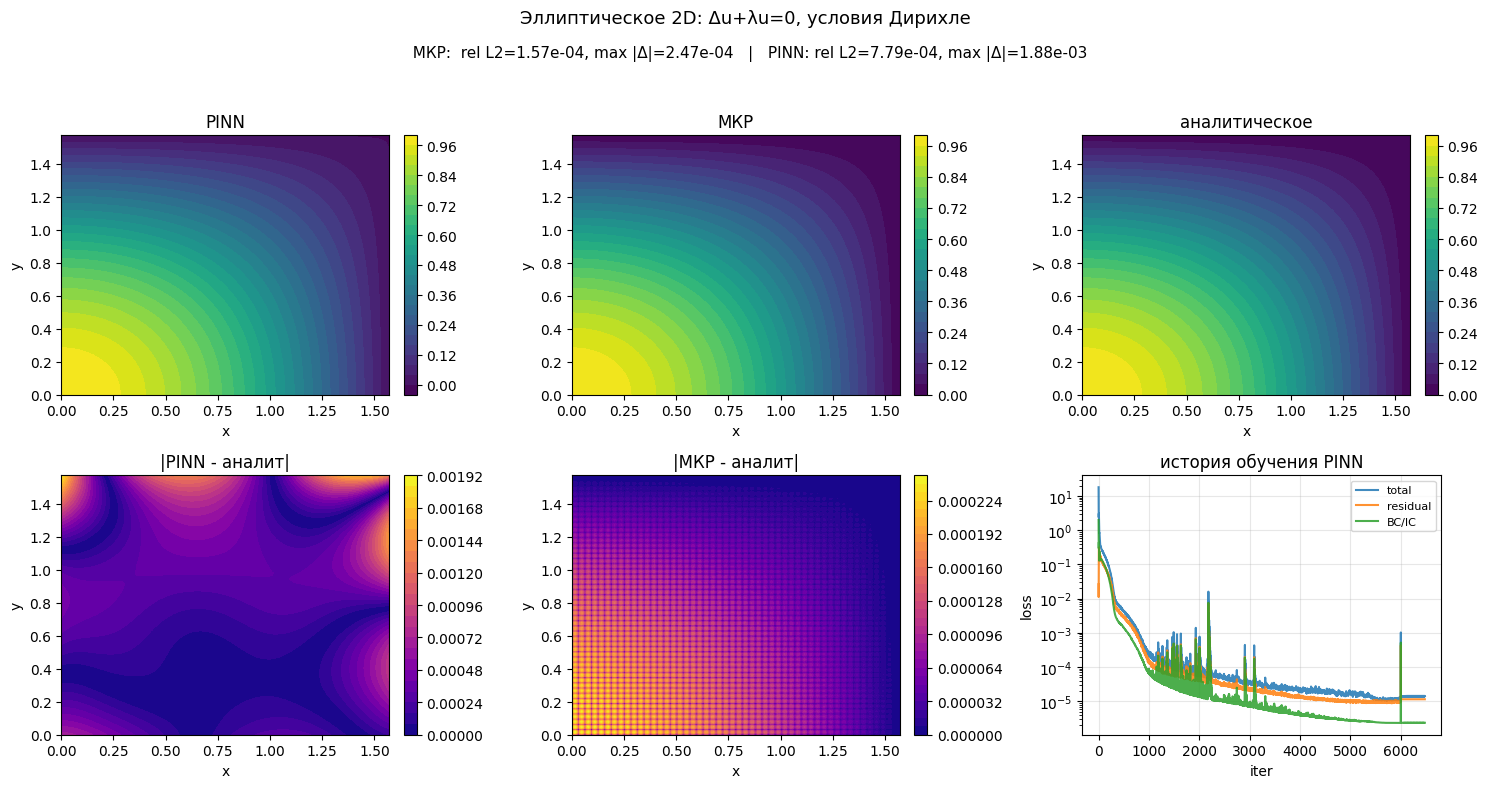


  Эллиптическое 2D: конвекция-диффузия-реакция, условия Дирихле
  PDE: Δu + 2u_x + 2u_y + 4u = 0
--- МКР ---
  МКР-эллиптика: nx=81, ny=81, hx=0.01963, hy=0.01963
  МКР время: 0.27s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=3000 random)


Adam:  25%|██▌       | 2005/8000 [00:50<02:30, 39.91it/s]

   2000 | L=1.84e-04 | res=8.55e-05 | cond=9.86e-05


Adam:  50%|█████     | 4007/8000 [01:40<01:38, 40.61it/s]

   4000 | L=4.70e-05 | res=2.88e-05 | cond=1.82e-05


Adam:  75%|███████▌  | 6006/8000 [02:30<00:51, 38.53it/s]

   6000 | L=1.35e-05 | res=8.78e-06 | cond=4.69e-06


Adam: 100%|██████████| 8000/8000 [03:19<00:00, 40.02it/s]


   8000 | L=8.71e-06 | res=6.07e-06 | cond=2.64e-06
L-BFGS (max 2500)
  L-BFGS   200 | L=2.79e-06
  L-BFGS   400 | L=2.79e-06
  L-BFGS   600 | L=2.79e-06
Done 223.2s | res=2.55e-06 | cond=2.38e-07 | total=2.79e-06
  PINN время: 223.24s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 5.262e-05   Max |Δ|: 3.009e-05
  PINN:   Rel L2: 5.595e-04   Max |Δ|: 6.220e-04


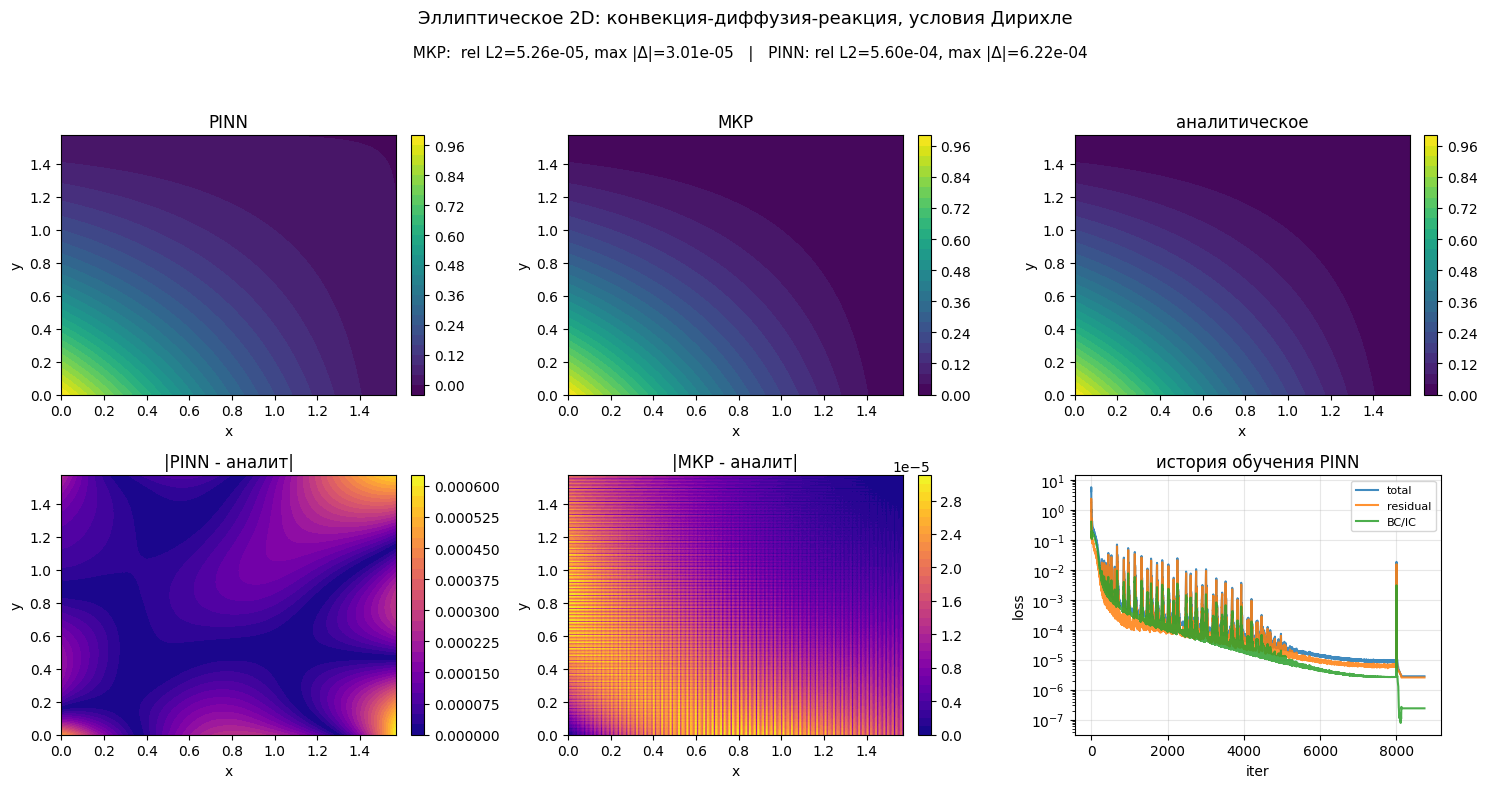

In [5]:
lr3_results = []
for task in LR3_TASKS:
    res = run_task(task, kind='elliptic_2d',
                   PINNSolver_cls=PINNSolver, device=DEVICE,
                   eval_n=EVAL_N, verbose=True)
    lr3_results.append(res)
    collect_row(res, task['name'])
    plot_compare_2d(res, save_to=OUT / f"elliptic_2d_{LR3_TASKS.index(task)+1}.png")

## Параболические уравнения 2D+t

Вид уравнения: $u_t = a_x u_{xx} + a_y u_{yy} + f(x,y,t)$. Включены изотропная и анизотропная диффузия, нестационарные граничные условия и вариант с условием Неймана на нижней грани.


  Параболическое 2D: изотропная диффузия, условия Дирихле
  PDE: u_t = a·Δu, Дирихле на 4 сторонах
--- МКР ---
  МКР-параболика 2D (ADI): nx=41, ny=41, nt=201, hx=0.0785, hy=0.0785, τ=0.01
  МКР время: 1.09s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=4000 random)


Adam:  25%|██▌       | 2005/8000 [01:26<04:06, 24.33it/s]

   2000 | L=8.06e-04 | res=2.42e-05 | cond=9.32e-04


Adam:  50%|█████     | 4003/8000 [02:50<02:47, 23.88it/s]

   4000 | L=7.33e-05 | res=2.77e-06 | cond=4.47e-05


Adam:  75%|███████▌  | 6004/8000 [04:13<01:21, 24.44it/s]

   6000 | L=1.10e-05 | res=1.32e-06 | cond=8.53e-06


Adam: 100%|██████████| 8000/8000 [05:38<00:00, 23.62it/s]


   8000 | L=6.03e-06 | res=1.96e-06 | cond=4.13e-06
L-BFGS (max 2500)
  L-BFGS   200 | L=5.84e-06
  L-BFGS   400 | L=5.97e-06
Done 363.4s | res=2.18e-06 | cond=4.13e-06 | total=6.40e-06
  PINN время: 363.46s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 9.765e-04   Max |Δ|: 1.539e-03
  PINN:   Rel L2: 1.474e-03   Max |Δ|: 4.447e-03


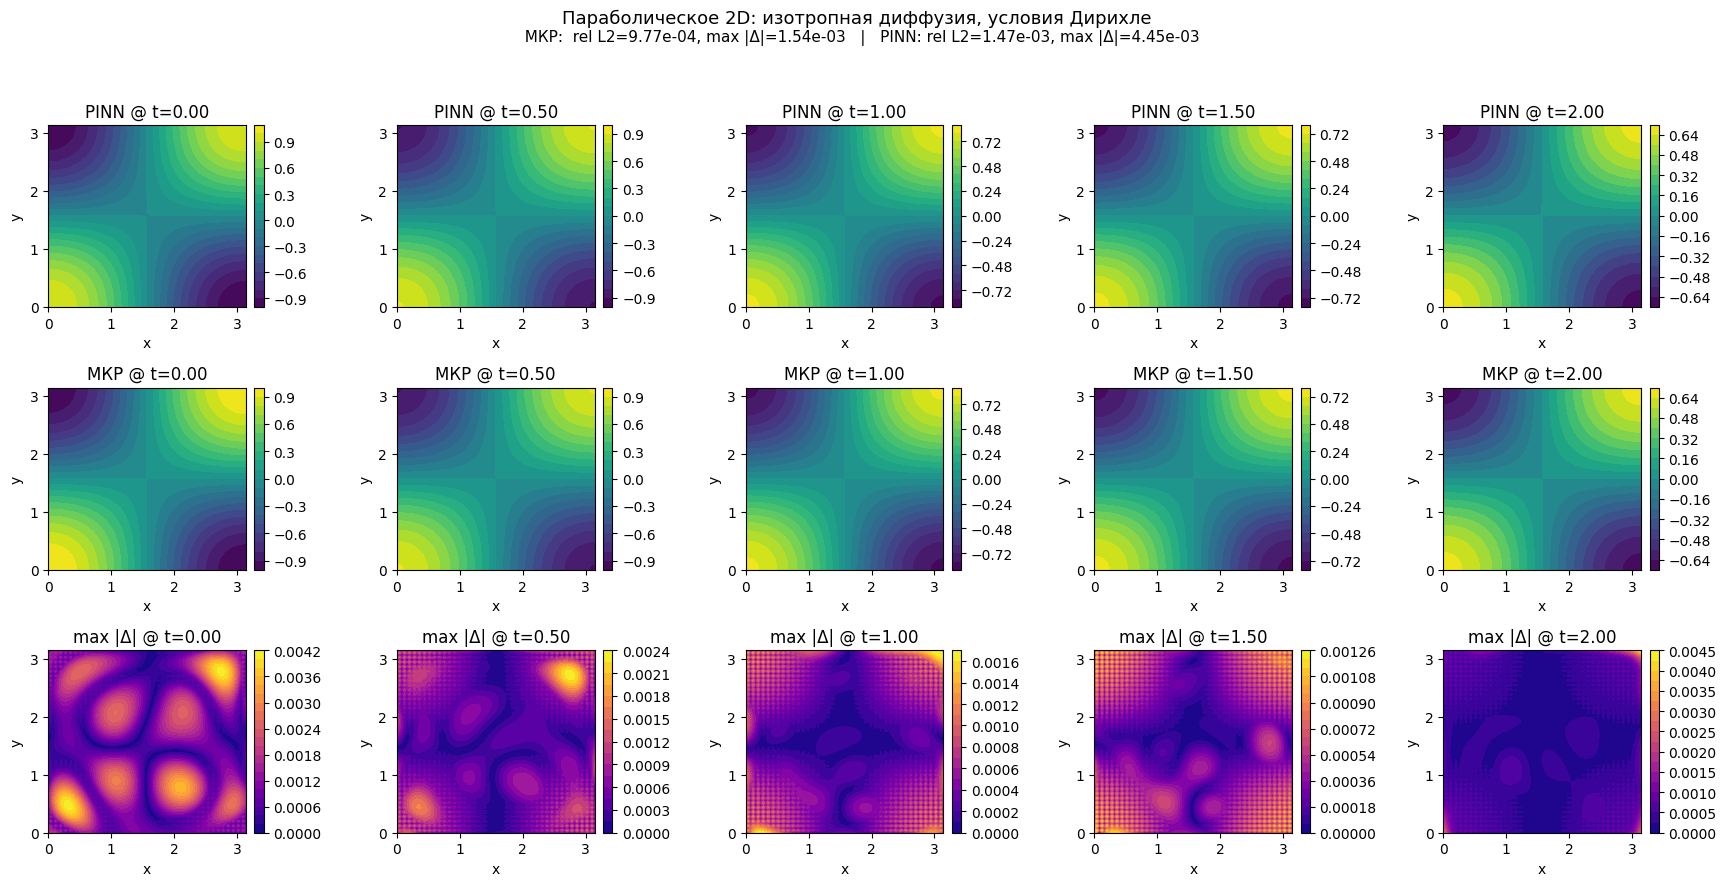


  Параболическое 2D: Нейман снизу, Дирихле на остальных гранях
  PDE: u_t = a·Δu, U=cos(2x)·sinh(y)·exp(-3at)
--- МКР ---
  МКР-параболика 2D (ADI): nx=41, ny=41, nt=401, hx=0.0393, hy=0.0173, τ=0.005
  МКР время: 7.68s
--- PINN ---
Adam (8000 ep, lr=0.001, coll=4000 random)


Adam:  25%|██▌       | 2001/8000 [01:31<04:30, 22.18it/s]

   2000 | L=2.06e-04 | res=5.40e-05 | cond=9.07e-05


Adam:  50%|█████     | 4002/8000 [03:00<02:57, 22.50it/s]

   4000 | L=2.38e-04 | res=1.15e-05 | cond=8.26e-05


Adam:  75%|███████▌  | 6003/8000 [04:28<01:28, 22.58it/s]

   6000 | L=6.37e-05 | res=6.06e-06 | cond=2.68e-05


Adam: 100%|██████████| 8000/8000 [05:56<00:00, 22.45it/s]


   8000 | L=2.18e-05 | res=6.10e-06 | cond=1.69e-05
L-BFGS (max 2500)
  L-BFGS   200 | L=2.24e-05
  L-BFGS   400 | L=3.35e-05
  L-BFGS   600 | L=3.32e-05
  L-BFGS   800 | L=3.52e-05
Done 402.5s | res=5.71e-06 | cond=1.84e-05 | total=4.19e-05
  PINN время: 402.59s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 5.091e-04   Max |Δ|: 5.777e-04
  PINN:   Rel L2: 3.825e-03   Max |Δ|: 7.259e-03


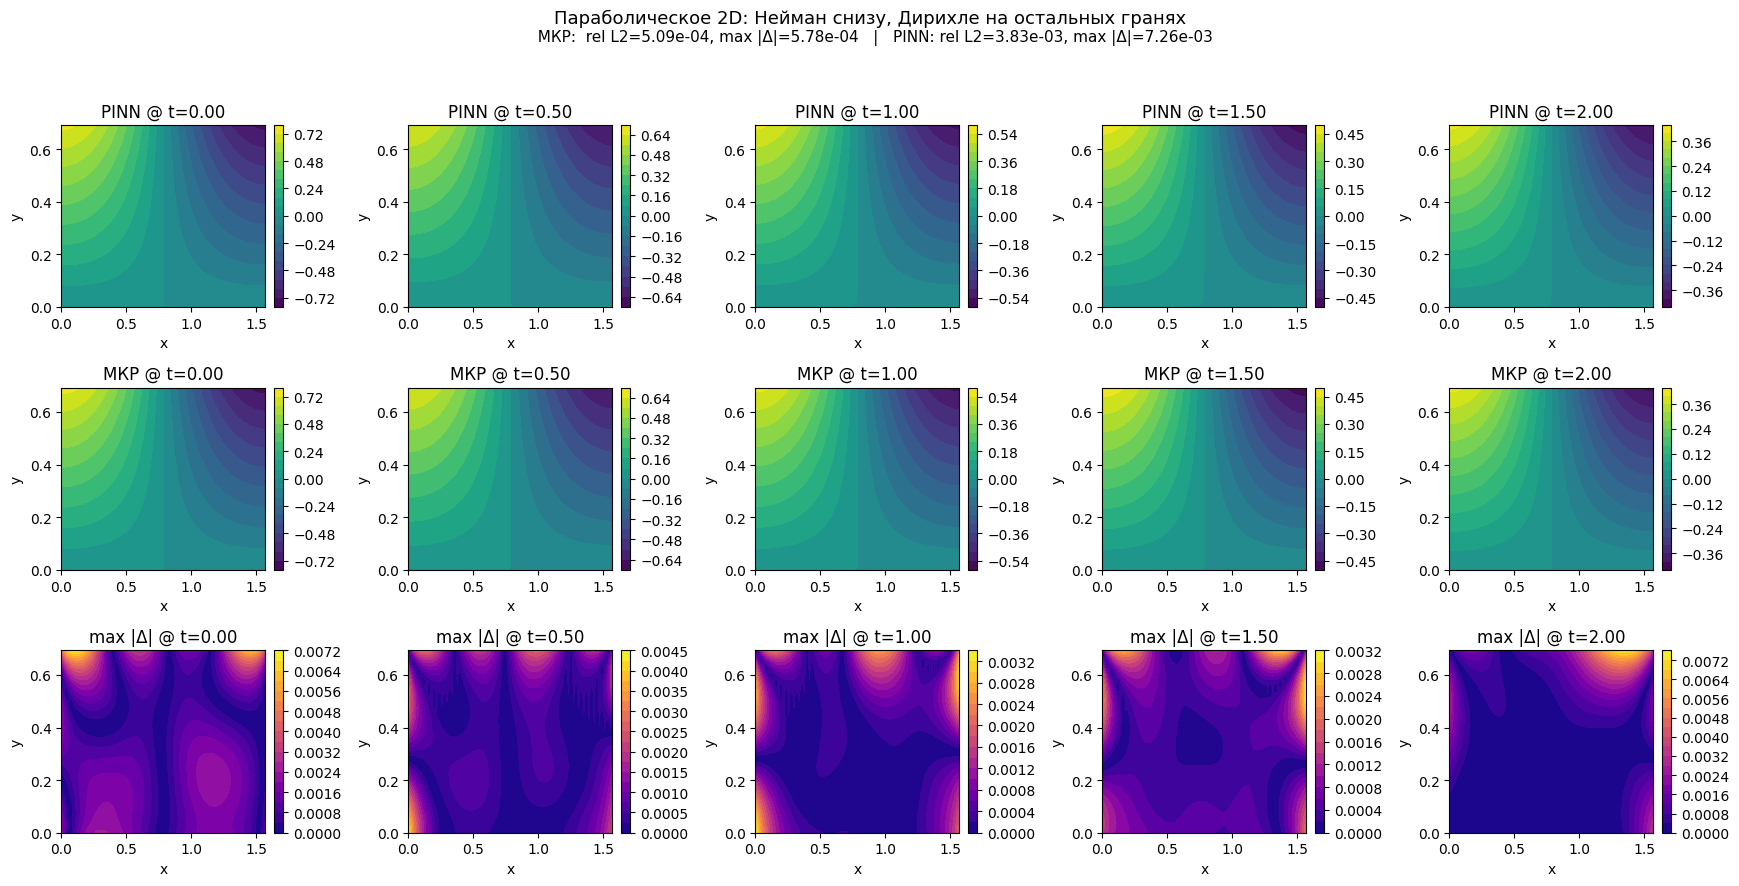


  Параболическое 2D: анизотропная диффузия с источником
  PDE: u_t = a u_xx + b u_yy + sin x · sin y · (μ cos μt + (a+b) sin μt)
--- МКР ---
  МКР-параболика 2D (ADI): nx=41, ny=61, nt=401, hx=0.0393, hy=0.0524, τ=0.00785
  МКР время: 8.82s
--- PINN ---
Adam (10000 ep, lr=0.001, coll=4000 random)


Adam:  20%|██        | 2003/10000 [01:28<05:47, 22.98it/s]

   2000 | L=4.89e-04 | res=6.21e-05 | cond=4.89e-04


Adam:  40%|████      | 4004/10000 [02:56<04:22, 22.88it/s]

   4000 | L=1.72e-04 | res=2.91e-05 | cond=1.32e-04


...

   6000 | L=9.15e-05 | res=2.14e-05 | cond=6.16e-05


Adam:  80%|████████  | 8003/10000 [05:51<01:27, 22.76it/s]

   8000 | L=5.58e-05 | res=1.86e-05 | cond=3.47e-05


Adam: 100%|██████████| 10000/10000 [07:18<00:00, 22.78it/s]


  10000 | L=6.21e-05 | res=2.17e-05 | cond=2.19e-05
L-BFGS (max 2500)
  L-BFGS   200 | L=5.25e-05
  L-BFGS   400 | L=4.62e-05
  L-BFGS   600 | L=4.81e-05
  L-BFGS   800 | L=4.44e-05
  L-BFGS  1000 | L=4.73e-05
Done 493.3s | res=2.12e-05 | cond=2.07e-05 | total=4.38e-05
  PINN время: 493.34s
--- Оценка на общей сетке ---
  МКР:    Rel L2: 3.326e-04   Max |Δ|: 5.131e-04
  PINN:   Rel L2: 3.672e-03   Max |Δ|: 1.049e-02


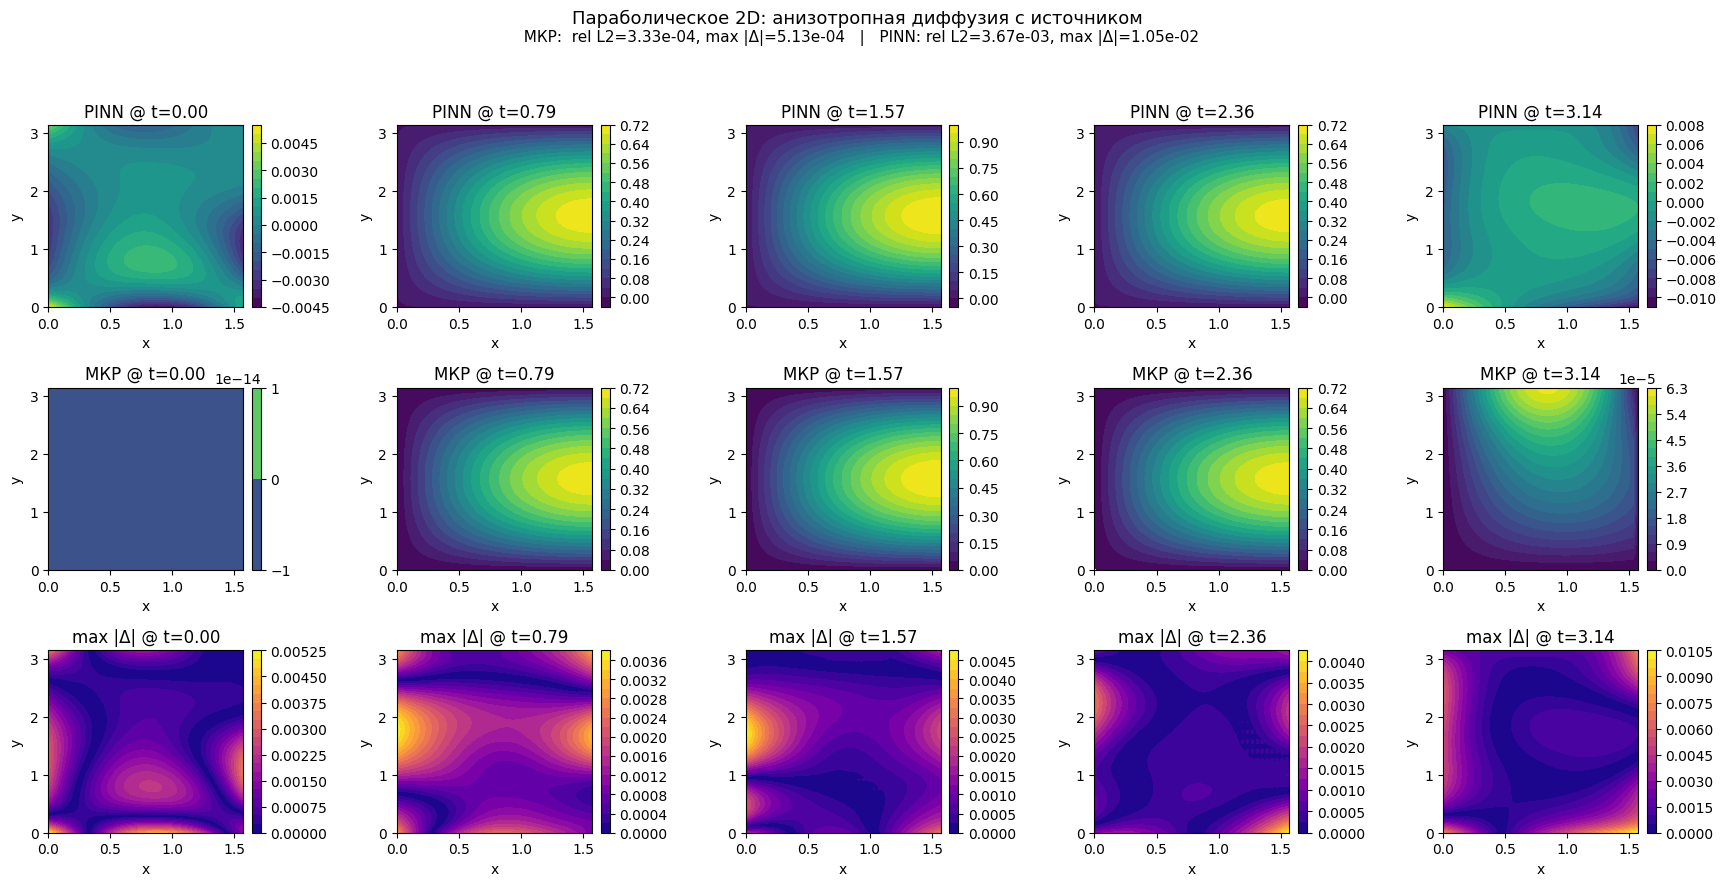

In [6]:
lr4_results = []
for task in LR4_TASKS:
    res = run_task(task, kind='parabolic_2d_adi',
                   PINNSolver_cls=PINNSolver, device=DEVICE,
                   eval_n=EVAL_N_2DT, verbose=True)
    lr4_results.append(res)
    collect_row(res, task['name'])
    plot_compare_2d_t_snapshots(
        res, save_to=OUT / f"parabolic_2d_{LR4_TASKS.index(task)+1}.png")

## Итоговая таблица

Относительная $L_2$-ошибка и максимальная абсолютная ошибка обоих методов посчитаны на единой сетке оценки; рядом — время решения.

In [7]:
print_summary_table(all_results)

Задача                                           | МКР: rel L2 / max|Δ|         | время    | PINN: rel L2 / max|Δ|        | время   
------------------------------------------------------------------------------------------------------------------------------------
Параболическое 1D: неоднородные условия Дирихле  | 3.25e-05 / 9.84e-05          |    0.15s | 1.14e-04 / 4.32e-04          |   88.72s
Параболическое 1D: нестационарные условия Неймана | 2.21e-04 / 2.36e-04          |    0.97s | 3.22e-04 / 4.29e-04          |  109.93s
Параболическое 1D: конвекция-диффузия, условия Робена | 4.49e-04 / 1.44e-03          |    1.14s | 3.79e-02 / 1.08e-01          |  246.70s
Гиперболическое 1D: условия Робена (α=-1, β=1)   | 5.61e-05 / 1.21e-04          |    0.09s | 7.82e-02 / 4.94e-01          |  369.30s
Гиперболическое 1D: с реакционным членом, нестационарные Дирихле | 1.31e-05 / 1.47e-05          |    0.09s | 3.83e-03 / 6.68e-03          |  307.58s
Гиперболическое 1D: с демпфированием и конвекци

## Сводные графики

Относительная $L_2$-ошибка и время решения по всем задачам (логарифмическая шкала).

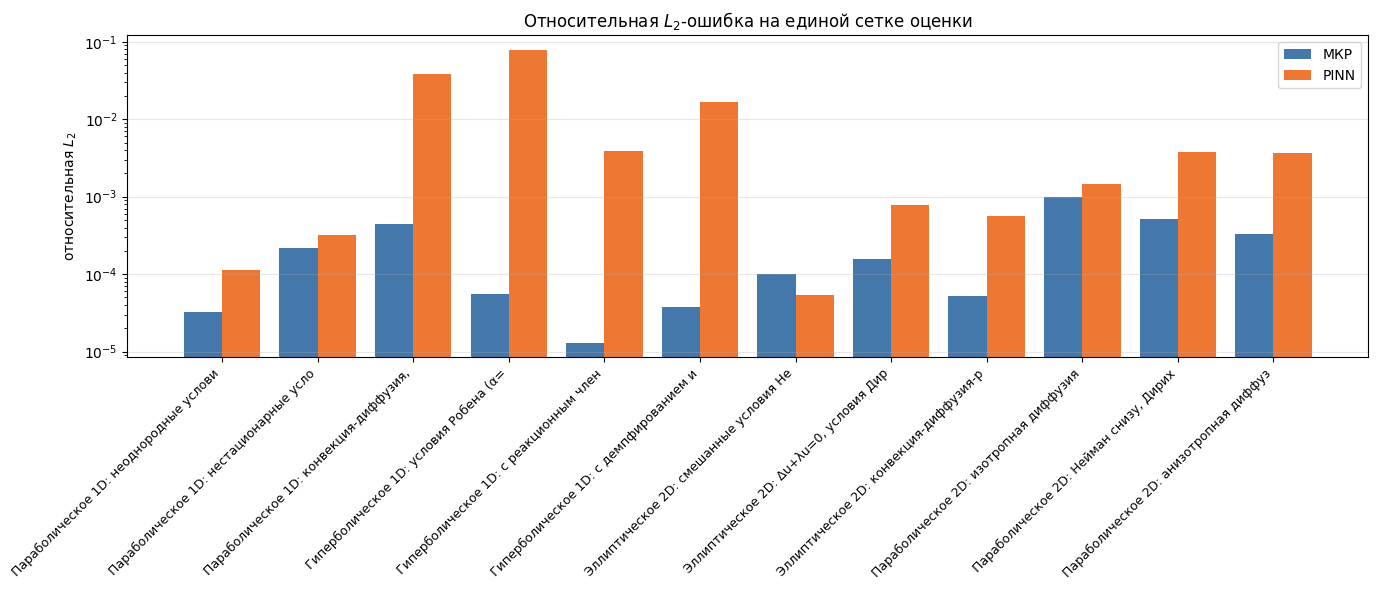

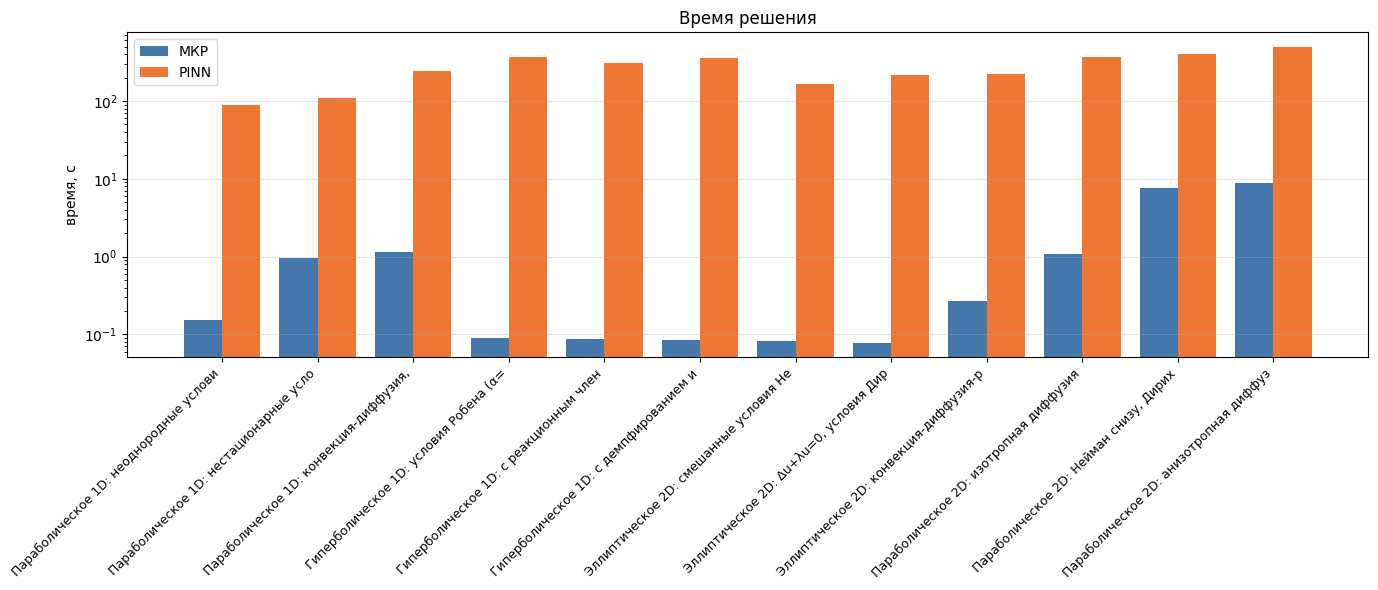

In [8]:
names = [r['name'][:38] for r in all_results]
fdm_rl  = [r['fdm_err']['rel_l2']  if r.get('fdm_err')  else np.nan for r in all_results]
pinn_rl = [r['pinn_err']['rel_l2'] if r.get('pinn_err') else np.nan for r in all_results]
x = np.arange(len(names)); w = 0.4
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, fdm_rl,  w, label='МКР',  color='#4477aa')
ax.bar(x + w/2, pinn_rl, w, label='PINN', color='#ee7733')
ax.set_yscale('log'); ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('относительная $L_2$'); ax.legend(); ax.grid(alpha=0.3, axis='y')
ax.set_title('Относительная $L_2$-ошибка на единой сетке оценки')
plt.tight_layout(); plt.savefig('outputs/summary_rel_l2.png', dpi=120, bbox_inches='tight'); plt.show()
fdm_t  = [r['fdm_time']  for r in all_results]
pinn_t = [r['pinn_time'] for r in all_results]
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, fdm_t,  w, label='МКР',  color='#4477aa')
ax.bar(x + w/2, pinn_t, w, label='PINN', color='#ee7733')
ax.set_yscale('log'); ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('время, с'); ax.legend(); ax.grid(alpha=0.3, axis='y')
ax.set_title('Время решения')
plt.tight_layout(); plt.savefig('outputs/summary_time.png', dpi=120, bbox_inches='tight'); plt.show()